**Publication execution note:** Existing outputs are historical and were preserved, not regenerated. Inputs resolve relative to the publication layout. New runs write to unique `runs/` directories, never to published models or results.

The 900 balanced cross-cell curves come from a second Candida albicans cell. AtomicJ ROI selection experimentally defined Nanodomain, Intermediate and Outside, with 300 curves per class. Later computational processing restored filename/class organization after anonymization/random renaming; restoration metadata did not define biological labels. Both balanced test archives represent the same cohort.

**Independent evaluation without retraining:** Restart the kernel and run ONLY the final code cell tagged `evaluation-only`. It is self-contained and loads the published model. Earlier code cells are tagged `retained-training` and blocked by default; explicit `RUN_RETAINED_TRAINING = True` is required to use them.

# VGG16 benchmark for *Candida albicans* AFM Force-Distance Curve Classification
## Pre-trained VGG16 without fine-tuning (Frozen)

This notebook implements the controlled **VGG16 frozen-feature-extractor benchmark**.

It preserves the classifier head used in the original VGG16 scripts:
`Flatten → Dense(512) → Dense(128) → Softmax(3)`, but corrects the preprocessing and
evaluation protocol for a fair comparison with the selected CNN.

**Controlled conditions**
- balanced training dataset: 3,000 images;
- 2,400 training / 600 validation samples;
- input size: 224 × 224 × 3;
- `SEED = 42`;
- batch size: 32;
- maximum 50 epochs;
- all 600 validation samples used every epoch;
- no L1/L2, Dropout, or data augmentation;
- VGG16 ImageNet preprocessing is used instead of `rescale=1/255`;
- same independent 900-curve test and same 16,384-curve map;
- same GPU/software environment as the controlled CNN experiments.

In this experiment the entire VGG16 convolutional base is frozen. Only the new
classification head is trained.

In [1]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# Portable publication layout; no machine-specific paths.
from pathlib import Path
import tempfile
_start = Path.cwd().resolve()
_roots = [p for p in (_start, *_start.parents)
          if (p / "notebooks").is_dir() and (p / "data/manifest.csv").is_file()]
if not _roots:
    raise FileNotFoundError("Start the kernel in the publication root or a notebook subdirectory.")
PROJECT_ROOT = _roots[0]
_candidates = [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent / "zenodo"]
ASSET_ROOT = next((p for p in _candidates
                   if (p / "data/candida_balanced_dataset.zip").is_file()), None)
if ASSET_ROOT is None:
    raise FileNotFoundError("Place Zenodo data/ and models/ in the publication root, or use the Zenodo github_snapshot layout.")
DATA_DIR = ASSET_ROOT / "data"
LABEL_MAPPING = PROJECT_ROOT / "data/labels/cross_cell_label_mapping.csv"
PUBLISHED_MODEL = ASSET_ROOT / "models/vgg16/frozen.h5"
_run_parent = PROJECT_ROOT / "runs/vgg16/frozen"
_run_parent.mkdir(parents=True, exist_ok=True)
RUN_DIR = Path(tempfile.mkdtemp(prefix="run-", dir=_run_parent))


from pathlib import Path
import os
import shutil
import zipfile
import time
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations: enabled")
except Exception as exc:
    print(f"TensorFlow deterministic operations could not be enabled: {exc}")

# -------------------------------------------------------------------------
# Shared experimental settings
# -------------------------------------------------------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

DATA_ZIP = (DATA_DIR / "candida_balanced_dataset.zip")
TEST_ZIP = (DATA_DIR / "candida_cross_cell_test_balanced_original.zip")
FULL_MAP_ZIP = (DATA_DIR / "candida_full_force_map_128x128.zip")

MODEL_DIR = (RUN_DIR / "models")
RESULTS_DIR = (RUN_DIR / "results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Python/TensorFlow device check:")
print("GPU(s):", tf.config.list_physical_devices("GPU"))


EXPERIMENT_NAME = "CNN_CAlbicans_VGG16_Frozen"
LEARNING_RATE = 1e-3
WORK_DIR = (RUN_DIR / "work")
TRAIN_EXTRACT_DIR = WORK_DIR / "training"
TEST_EXTRACT_DIR = WORK_DIR / "testing"
FULL_MAP_EXTRACT_DIR = WORK_DIR / "full_map"
MODEL_PATH = MODEL_DIR / "frozen.h5"
print("Experiment:", EXPERIMENT_NAME)
print("Model output path:", MODEL_PATH)
print("Learning rate:", LEARNING_RATE)


2026-08-27 17:08:18.386997: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-27 17:08:18.716602: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-27 17:08:18.716649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-27 17:08:18.726623: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-27 17:08:18.766981: I tensorflow/core/platform/cpu_feature_guar

TensorFlow deterministic operations: enabled
TensorFlow version: 2.15.0
Python/TensorFlow device check:
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: CNN_CAlbicans_VGG16_Frozen
Model output path: Models/CNN_CAlbicans_VGG16_Frozen.h5
Learning rate: 0.001


2026-08-27 17:08:24.466872: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 17:08:24.840171: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 17:08:24.840384: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


def extract_zip_clean(zip_path, destination):
    destination = Path(destination)
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(destination)
    return destination

def locate_class_root(root, expected_classes):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        children = {p.name for p in candidate.iterdir() if p.is_dir()}
        if set(expected_classes).issubset(children):
            return candidate
    raise RuntimeError(
        f"Could not find a directory containing all classes: {expected_classes}"
    )

def class_names_from_iterator(iterator):
    ordered = sorted(iterator.class_indices.items(), key=lambda kv: kv[1])
    return [name for name, _ in ordered]

def natural_number_key(path):
    match = re.search(r"(\d+)(?=\.[^.]+$)", Path(path).name)
    return int(match.group(1)) if match else Path(path).name

def count_trainable_and_nontrainable(model):
    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    return trainable, non_trainable

def make_paper_confusion_matrix(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(cm, cmap="gray")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = int(cm[i, j])
            text = f"True Positive\n{value}" if i == j else str(value)
            ax.text(
                j, i, text,
                ha="center", va="center",
                color="black" if value > threshold else "white"
            )

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


## 1. Balanced training and validation dataset

In [3]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


EXPECTED_CLASSES = ["Intermediate", "Nanodomain", "Outside"]

extract_zip_clean(DATA_ZIP, TRAIN_EXTRACT_DIR)
base_dir = locate_class_root(TRAIN_EXTRACT_DIR, EXPECTED_CLASSES)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

class_file_counts = {
    cls: sum(
        1 for p in (base_dir / cls).rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    )
    for cls in EXPECTED_CLASSES
}
print("Original class counts:", class_file_counts)

assert class_file_counts == {
    "Intermediate": 1000,
    "Nanodomain": 1000,
    "Outside": 1000,
}

# IMPORTANT:
# VGG16 ImageNet weights expect keras.applications.vgg16.preprocess_input.
# Do NOT combine this with rescale=1/255.
data_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
)

train_iterator = data_generator.flow_from_directory(
    base_dir,
    subset="training",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
)

validation_iterator = data_generator.flow_from_directory(
    base_dir,
    subset="validation",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
)

CLASS_NAMES = class_names_from_iterator(validation_iterator)

print("Class indices:", validation_iterator.class_indices)
print("Ordered classes:", CLASS_NAMES)
print("Training samples:", train_iterator.samples)
print("Validation samples:", validation_iterator.samples)

assert train_iterator.samples == 2400
assert validation_iterator.samples == 600
assert CLASS_NAMES == EXPECTED_CLASSES


Original class counts: {'Intermediate': 1000, 'Nanodomain': 1000, 'Outside': 1000}
Found 2400 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
Class indices: {'Intermediate': 0, 'Nanodomain': 1, 'Outside': 2}
Ordered classes: ['Intermediate', 'Nanodomain', 'Outside']
Training samples: 2400
Validation samples: 600


## 2. Pre-trained VGG16 frozen architecture

In [4]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

vgg_base = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

for layer in vgg_base.layers:
    layer.trainable = False

x = layers.Flatten(name="flatten")(vgg_base.output)
x = layers.Dense(512, activation="relu", name="dense_512")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
outputs = layers.Dense(3, activation="softmax", name="class_probabilities")(x)

model = Model(
    inputs=vgg_base.input,
    outputs=outputs,
    name=EXPERIMENT_NAME,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

trainable_params, non_trainable_params = count_trainable_and_nontrainable(model)
print("Total parameters:", model.count_params())
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

assert model.count_params() == 27_626_307
assert trainable_params == 12_911_619
assert non_trainable_params == 14_714_688
assert all(not layer.trainable for layer in vgg_base.layers)

print("VGG16 convolutional base: fully frozen")


2026-08-27 18:09:28.501412: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 18:09:28.501623: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 18:09:28.501656: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 18:09:28.813605: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 18:09:28.813790: I external/local_xla/xla/stream_executor

Model: "CNN_CAlbicans_VGG16_Frozen"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 

## 3. Training

In [5]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

start_time = time.perf_counter()

history = model.fit(
    train_iterator,
    epochs=EPOCHS,
    validation_data=validation_iterator,
    callbacks=[checkpoint],
    verbose=1,
)

training_time_minutes = (time.perf_counter() - start_time) / 60.0

history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"
history_df.to_csv(RESULTS_DIR / f"{EXPERIMENT_NAME}_history.csv")

best_epoch = int(history_df["val_loss"].idxmin())
best_val_loss = float(history_df.loc[best_epoch, "val_loss"])
best_val_accuracy = float(history_df.loc[best_epoch, "val_accuracy"])

summary = {
    "experiment": EXPERIMENT_NAME,
    "seed": SEED,
    "epochs_requested": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "training_samples": int(train_iterator.samples),
    "validation_samples": int(validation_iterator.samples),
    "training_time_minutes": training_time_minutes,
    "best_epoch_by_val_loss": best_epoch,
    "best_val_loss": best_val_loss,
    "val_accuracy_at_best_val_loss_epoch": best_val_accuracy,
    "total_parameters": int(model.count_params()),
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": non_trainable_params,
    "preprocessing": "keras.applications.vgg16.preprocess_input",
}

with open(RESULTS_DIR / f"{EXPERIMENT_NAME}_training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(summary)


Epoch 1/50


2026-08-27 18:09:34.472711: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-08-27 18:09:35.532556: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f8324bb55e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-27 18:09:35.532599: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 5000 Ada Generation Laptop GPU, Compute Capability 8.9
2026-08-27 18:09:35.542087: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787875775.625515  400004 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 [==============================] - ETA: 0s - loss: 2.9865 - accuracy: 0.9171
Epoch 1: val_loss improved from inf to 0.41753, saving model to Models/CNN_CAlbicans_VGG16_Frozen.h5


/home/adrian/anaconda3/envs/TFQ/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


75/75 [==============================] - 16s 178ms/step - loss: 2.9865 - accuracy: 0.9171 - val_loss: 0.4175 - val_accuracy: 0.9750
Epoch 2/50
75/75 [==============================] - ETA: 0s - loss: 0.1492 - accuracy: 0.9883
Epoch 2: val_loss improved from 0.41753 to 0.33221, saving model to Models/CNN_CAlbicans_VGG16_Frozen.h5
75/75 [==============================] - 13s 168ms/step - loss: 0.1492 - accuracy: 0.9883 - val_loss: 0.3322 - val_accuracy: 0.9817
Epoch 3/50
75/75 [==============================] - ETA: 0s - loss: 0.1165 - accuracy: 0.9875
Epoch 3: val_loss did not improve from 0.33221
75/75 [==============================] - 13s 171ms/step - loss: 0.1165 - accuracy: 0.9875 - val_loss: 0.4379 - val_accuracy: 0.9767
Epoch 4/50
75/75 [==============================] - ETA: 0s - loss: 0.0674 - accuracy: 0.9917
Epoch 4: val_loss improved from 0.33221 to 0.30393, saving model to Models/CNN_CAlbicans_VGG16_Frozen.h5
75/75 [==============================] - 13s 175ms/step - loss: 0

Epoch 30/50
75/75 [==============================] - ETA: 0s - loss: 2.6854e-07 - accuracy: 1.0000
Epoch 30: val_loss did not improve from 0.15151
75/75 [==============================] - 15s 202ms/step - loss: 2.6854e-07 - accuracy: 1.0000 - val_loss: 0.1692 - val_accuracy: 0.9900
Epoch 31/50
75/75 [==============================] - ETA: 0s - loss: 2.6039e-07 - accuracy: 1.0000
Epoch 31: val_loss did not improve from 0.15151
75/75 [==============================] - 14s 194ms/step - loss: 2.6039e-07 - accuracy: 1.0000 - val_loss: 0.1694 - val_accuracy: 0.9900
Epoch 32/50
75/75 [==============================] - ETA: 0s - loss: 2.5036e-07 - accuracy: 1.0000
Epoch 32: val_loss did not improve from 0.15151
75/75 [==============================] - 15s 196ms/step - loss: 2.5036e-07 - accuracy: 1.0000 - val_loss: 0.1697 - val_accuracy: 0.9900
Epoch 33/50
75/75 [==============================] - ETA: 0s - loss: 2.4177e-07 - accuracy: 1.0000
Epoch 33: val_loss did not improve from 0.15151
75/7

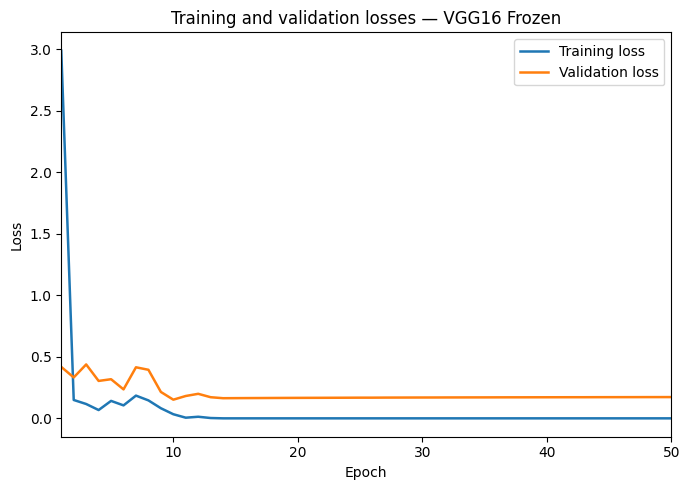

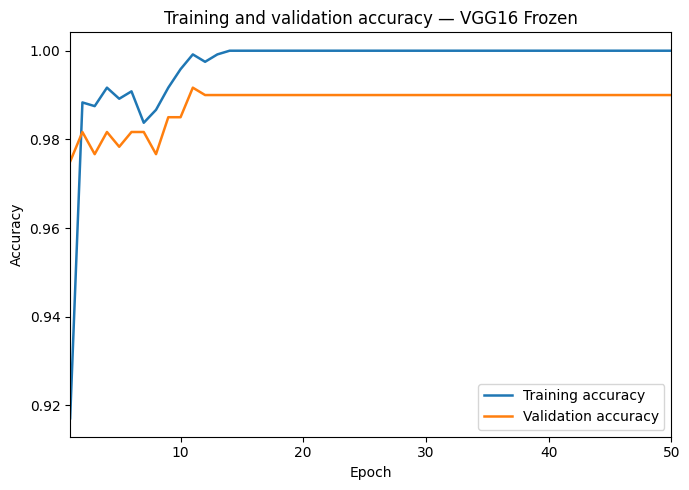

In [6]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


def plot_history(history_df, prefix, title_suffix=""):
    epochs_axis = np.arange(1, len(history_df) + 1)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(epochs_axis, history_df["loss"], linewidth=1.8, label="Training loss")
    ax.plot(epochs_axis, history_df["val_loss"], linewidth=1.8, label="Validation loss")
    ax.set_title(f"Training and validation losses{title_suffix}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xlim(1, len(epochs_axis))
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"{prefix}_Loss.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(epochs_axis, history_df["accuracy"], linewidth=1.8, label="Training accuracy")
    ax.plot(epochs_axis, history_df["val_accuracy"], linewidth=1.8, label="Validation accuracy")
    ax.set_title(f"Training and validation accuracy{title_suffix}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_xlim(1, len(epochs_axis))
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"{prefix}_Accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_history(history_df, EXPERIMENT_NAME, " — VGG16 Frozen")

## 4. Validation performance

19/19 [==============================] - 3s 156ms/step
Validation accuracy: 0.9850
Macro F1:            0.9850
Weighted F1:         0.9850

              precision    recall  f1-score   support

Intermediate     0.9799    0.9750    0.9774       200
  Nanodomain     0.9950    0.9950    0.9950       200
     Outside     0.9801    0.9850    0.9825       200

    accuracy                         0.9850       600
   macro avg     0.9850    0.9850    0.9850       600
weighted avg     0.9850    0.9850    0.9850       600



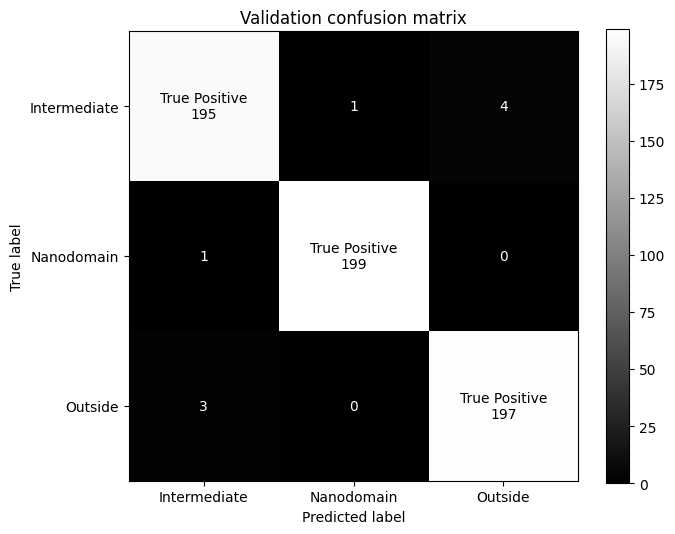

In [7]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


best_model = load_model(MODEL_PATH)

validation_iterator.reset()
val_probabilities = best_model.predict(validation_iterator, verbose=1)
val_predictions = np.argmax(val_probabilities, axis=1)
val_true = validation_iterator.classes

val_accuracy = accuracy_score(val_true, val_predictions)
val_cm = confusion_matrix(val_true, val_predictions)

report_dict = classification_report(
    val_true,
    val_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

macro_f1 = float(report_dict["macro avg"]["f1-score"])
weighted_f1 = float(report_dict["weighted avg"]["f1-score"])

print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Macro F1:            {macro_f1:.4f}")
print(f"Weighted F1:         {weighted_f1:.4f}")
print()
print(classification_report(
    val_true,
    val_predictions,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

pd.DataFrame(report_dict).T.to_csv(
    RESULTS_DIR / f"{EXPERIMENT_NAME}_validation_report.csv"
)

validation_summary = {
    "accuracy": float(val_accuracy),
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}
with open(RESULTS_DIR / f"{EXPERIMENT_NAME}_validation_summary.json", "w") as f:
    json.dump(validation_summary, f, indent=2)

make_paper_confusion_matrix(
    val_cm,
    CLASS_NAMES,
    "Validation confusion matrix",
    RESULTS_DIR / f"{EXPERIMENT_NAME}_Validation_ConfusionMatrix.png"
)


## 5. Independent balanced blind test from the second cell

In [8]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


# ============================================================
# Independent balanced blind test from a second C. albicans cell
# ============================================================
GROUND_TRUTH_CSV = LABEL_MAPPING
EXPECTED_TEST_COUNTS = {
    "Intermediate": 300,
    "Nanodomain": 300,
    "Outside": 300,
}
EXPECTED_TEST_TOTAL = 900

extract_zip_clean(TEST_ZIP, TEST_EXTRACT_DIR)

blind_test_files = sorted(
    [
        p for p in TEST_EXTRACT_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ],
    key=natural_number_key,
)

print("Independent blind-test images found:", len(blind_test_files))
assert len(blind_test_files) == EXPECTED_TEST_TOTAL

def load_vgg_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    # Same preprocessing expected by VGG16 ImageNet weights.
    image = preprocess_input(image)
    return image

blind_paths = [str(p) for p in blind_test_files]

blind_ds = (
    tf.data.Dataset.from_tensor_slices(blind_paths)
    .map(load_vgg_image, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

blind_model = load_model(MODEL_PATH)

for warmup_batch in blind_ds.take(1):
    _ = blind_model(warmup_batch, training=False)

t0 = time.perf_counter()
blind_probabilities = blind_model.predict(blind_ds, verbose=1)
blind_time_seconds = time.perf_counter() - t0

blind_predictions = np.argmax(blind_probabilities, axis=1)
blind_max_prob = np.max(blind_probabilities, axis=1)

blind_df = pd.DataFrame({
    "filename": [p.name for p in blind_test_files],
    "predicted_label": [CLASS_NAMES[i] for i in blind_predictions],
    "maximum_predicted_probability": blind_max_prob,
})

for idx, cls in enumerate(CLASS_NAMES):
    blind_df[f"prob_{cls}"] = blind_probabilities[:, idx]

blind_df.to_csv(
    RESULTS_DIR / f"{EXPERIMENT_NAME}_blind_test_predictions.csv",
    index=False,
)

predicted_counts = (
    blind_df["predicted_label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)
known_counts = pd.Series(EXPECTED_TEST_COUNTS).reindex(CLASS_NAMES)

aggregate = pd.DataFrame({
    "known_aggregate_count": known_counts,
    "predicted_count": predicted_counts,
})
aggregate["difference"] = (
    aggregate["predicted_count"] - aggregate["known_aggregate_count"]
)

print("\nKnown aggregate composition:")
print(known_counts)
print("\nPredicted distribution:")
print(predicted_counts)
print("\nAggregate comparison:")
print(aggregate)

aggregate.to_csv(
    RESULTS_DIR / f"{EXPERIMENT_NAME}_blind_test_aggregate_comparison.csv"
)

blind_ms_curve = blind_time_seconds / EXPECTED_TEST_TOTAL * 1000
blind_throughput = EXPECTED_TEST_TOTAL / blind_time_seconds

print(f"\nBlind-test inference time: {blind_time_seconds:.2f} s")
print(f"Time per curve: {blind_ms_curve:.3f} ms")
print(f"Throughput: {blind_throughput:.1f} curves/s")
print(f"Mean maximum predicted probability: {blind_max_prob.mean():.4f}")
print(f"Median maximum predicted probability: {np.median(blind_max_prob):.4f}")

# Optional sample-level supervised evaluation.
if GROUND_TRUTH_CSV.exists():
    labels_df = pd.read_csv(GROUND_TRUTH_CSV)[["filename", "true_label"]].copy()

    if len(labels_df) != EXPECTED_TEST_TOTAL:
        raise ValueError("Ground-truth CSV must contain exactly 900 rows.")
    if labels_df["filename"].duplicated().any():
        raise ValueError("Duplicate filenames in ground-truth CSV.")

    true_counts = (
        labels_df["true_label"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    )
    if not true_counts.equals(known_counts):
        raise ValueError("Ground-truth CSV does not match 300/300/300 composition.")

    evaluated = blind_df.merge(
        labels_df,
        on="filename",
        how="left",
        validate="one_to_one",
    )
    if evaluated["true_label"].isna().any():
        raise ValueError("Missing sample-level labels.")

    y_true = evaluated["true_label"].to_numpy()
    y_pred = evaluated["predicted_label"].to_numpy()

    test_accuracy = accuracy_score(y_true, y_pred)
    test_report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    print("\nIndependent supervised test")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"Macro F1: {test_report['macro avg']['f1-score']:.4f}")
    print(classification_report(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))
else:
    print(
        "\nNo cross_cell_label_mapping.csv found. "
        "Aggregate counts are reported, but no sample-level test accuracy/F1."
    )


Independent blind-test images found: 900
29/29 [==============================] - 2s 81ms/step

Known aggregate composition:
Intermediate    300
Nanodomain      300
Outside         300
dtype: int64

Predicted distribution:
predicted_label
Intermediate    275
Nanodomain      302
Outside         323
Name: count, dtype: int64

Aggregate comparison:
              known_aggregate_count  predicted_count  difference
Intermediate                    300              275         -25
Nanodomain                      300              302           2
Outside                         300              323          23

Blind-test inference time: 2.49 s
Time per curve: 2.766 ms
Throughput: 361.5 curves/s
Mean maximum predicted probability: 0.9987
Median maximum predicted probability: 1.0000

No TestingAdrian_labels.csv found. Aggregate counts are reported, but no sample-level test accuracy/F1.


## 6. Complete 16,384-curve AFM map

In [9]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")


# ============================================================
# Complete 16,384-curve AFM map from the same independent cell
# ============================================================
extract_zip_clean(FULL_MAP_ZIP, FULL_MAP_EXTRACT_DIR)

full_map_files = sorted(
    [
        p for p in FULL_MAP_EXTRACT_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ],
    key=natural_number_key,
)

assert len(full_map_files) == 16384, (
    f"Expected 16,384 curves, found {len(full_map_files)}."
)

full_paths = [str(p) for p in full_map_files]

full_ds = (
    tf.data.Dataset.from_tensor_slices(full_paths)
    .map(load_vgg_image, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

map_model = load_model(MODEL_PATH)

for warmup_batch in full_ds.take(1):
    _ = map_model(warmup_batch, training=False)

t0 = time.perf_counter()
full_probabilities = map_model.predict(full_ds, verbose=1)
full_time_seconds = time.perf_counter() - t0

full_predictions = np.argmax(full_probabilities, axis=1)
full_max_prob = np.max(full_probabilities, axis=1)

full_df = pd.DataFrame({
    "filename": [p.name for p in full_map_files],
    "predicted_label": [CLASS_NAMES[i] for i in full_predictions],
    "maximum_predicted_probability": full_max_prob,
})
for idx, cls in enumerate(CLASS_NAMES):
    full_df[f"prob_{cls}"] = full_probabilities[:, idx]

full_df.to_csv(
    RESULTS_DIR / f"{EXPERIMENT_NAME}_full_map_predictions.csv",
    index=False,
)

full_counts = (
    full_df["predicted_label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

full_ms_curve = full_time_seconds / len(full_map_files) * 1000
full_throughput = len(full_map_files) / full_time_seconds

print("\nComplete-map predicted counts:")
print(full_counts)
print(f"\nComplete-map inference time: {full_time_seconds:.2f} s")
print(f"Time per curve: {full_ms_curve:.3f} ms")
print(f"Throughput: {full_throughput:.1f} curves/s")

performance_summary = pd.DataFrame([
    {
        "experiment": "independent_balanced_900",
        "n_curves": EXPECTED_TEST_TOTAL,
        "total_time_seconds": blind_time_seconds,
        "ms_per_curve": blind_ms_curve,
        "curves_per_second": blind_throughput,
    },
    {
        "experiment": "complete_map_16384",
        "n_curves": len(full_map_files),
        "total_time_seconds": full_time_seconds,
        "ms_per_curve": full_ms_curve,
        "curves_per_second": full_throughput,
    },
])
performance_summary.to_csv(
    RESULTS_DIR / f"{EXPERIMENT_NAME}_computational_performance.csv",
    index=False,
)
print("\nComputational performance summary:")
print(performance_summary)


512/512 [==============================] - 42s 82ms/step

Complete-map predicted counts:
predicted_label
Intermediate    2721
Nanodomain      8584
Outside         5079
Name: count, dtype: int64

Complete-map inference time: 42.81 s
Time per curve: 2.613 ms
Throughput: 382.7 curves/s

Computational performance summary:
                 experiment  n_curves  total_time_seconds  ms_per_curve  \
0  independent_balanced_900       900            2.489353      2.765948   
1        complete_map_16384     16384           42.814289      2.613177   

   curves_per_second  
0          361.53967  
1          382.67598  


## 7. Output files

The principal reusable model is:
`Models/CNN_CAlbicans_VGG16_Frozen.h5`

Results include training history, validation metrics, confusion matrix,
independent 900-curve predictions, complete-map predictions, and timing.

## Independent cross-cell sample-level evaluation using the 900 labelled curves

This section evaluates the persisted **VGG16 Frozen** model on the same independent set of
900 force-distance curve images acquired from a different *Candida albicans* cell.

The 900 curves had originally been selected from experimentally defined ROIs in the
adhesion map, comprising 300 Nanodomain, 300 Intermediate, and 300 Outside curves.
The anonymised images have now been reorganised into those three experimental classes
to enable sample-level evaluation.

No model retraining is performed here. The persisted H5 model is reloaded and evaluated
using exactly the same VGG16 `preprocess_input` transformation used during training and
validation. The section reports accuracy, balanced accuracy, precision, recall, F1-score,
macro-F1, weighted-F1, a sample-level confusion matrix, and true-versus-predicted class
counts.

2026-08-28 00:27:13.716387: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-28 00:27:13.773256: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-28 00:27:13.773292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-28 00:27:13.774409: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-28 00:27:13.781685: I tensorflow/core/platform/cpu_feature_guar

Labelled test ZIP: /home/adrian/anaconda3/envs/TFQ/Archivos/CNN/TestingAdrian_Labelled.zip
Labels CSV: /home/adrian/anaconda3/envs/TFQ/Archivos/CNN/TestingAdrian_labels.csv
Persisted VGG16 model: Models/CNN_CAlbicans_VGG16_Frozen.h5
Ground-truth class counts: {'Intermediate': 300, 'Nanodomain': 300, 'Outside': 300}
Class order used by the model: ['Intermediate', 'Nanodomain', 'Outside']


2026-08-28 00:27:17.919184: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-28 00:27:18.039117: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-28 00:27:18.039179: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-28 00:27:18.042310: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-28 00:27:18.042404: I external/local_xla/xla/stream_executor

29/29 [==============================] - 6s 96ms/step

Independent cross-cell sample-level performance
------------------------------------------------
Accuracy:          0.9722
Balanced accuracy: 0.9722
Macro F1:          0.9721
Weighted F1:       0.9721
Correct:           875/900
Errors:            25/900

Classification report:
              precision    recall  f1-score   support

Intermediate     1.0000    0.9167    0.9565       300
  Nanodomain     0.9934    1.0000    0.9967       300
     Outside     0.9288    1.0000    0.9631       300

    accuracy                         0.9722       900
   macro avg     0.9741    0.9722    0.9721       900
weighted avg     0.9741    0.9722    0.9721       900


Confusion matrix:
[[275   2  23]
 [  0 300   0]
 [  0   0 300]]


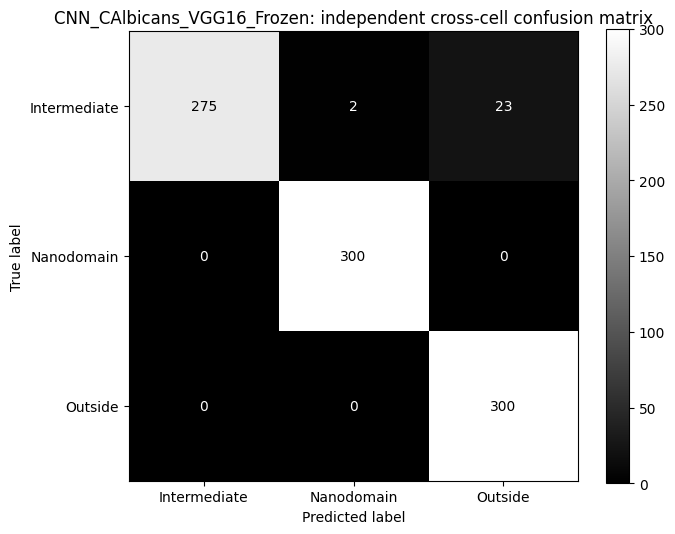

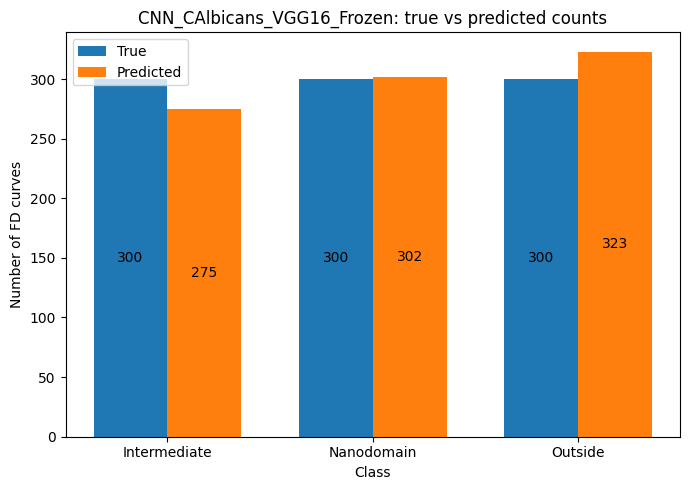


Inference time for 900 curves: 6.52 s
Average time per curve: 7.239 ms
Throughput: 138.1 curves/s

Saved outputs in: /home/adrian/anaconda3/envs/TFQ/Archivos/CNN/ScriptsVGG de IA/Results


In [1]:

# ============================================================
# Independent cross-cell evaluation: 900 labelled FD curves
# SELF-CONTAINED: may be run after restarting the kernel.
# ============================================================

from pathlib import Path
import shutil
import zipfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

# -------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------
IMG_SIZE = 224
BATCH_SIZE = 32

EXPERIMENT_NAME = "CNN_CAlbicans_VGG16_Frozen"

CLASS_NAMES = [
    "Intermediate",
    "Nanodomain",
    "Outside",
]

# Portable publication layout; no machine-specific paths.
from pathlib import Path
import tempfile
_start = Path.cwd().resolve()
_roots = [p for p in (_start, *_start.parents)
          if (p / "notebooks").is_dir() and (p / "data/manifest.csv").is_file()]
if not _roots:
    raise FileNotFoundError("Start the kernel in the publication root or a notebook subdirectory.")
PROJECT_ROOT = _roots[0]
_candidates = [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent / "zenodo"]
ASSET_ROOT = next((p for p in _candidates
                   if (p / "data/candida_balanced_dataset.zip").is_file()), None)
if ASSET_ROOT is None:
    raise FileNotFoundError("Place Zenodo data/ and models/ in the publication root, or use the Zenodo github_snapshot layout.")
DATA_DIR = ASSET_ROOT / "data"
LABEL_MAPPING = PROJECT_ROOT / "data/labels/cross_cell_label_mapping.csv"
PUBLISHED_MODEL = ASSET_ROOT / "models/vgg16/frozen.h5"
_run_parent = PROJECT_ROOT / "runs/vgg16/frozen"
_run_parent.mkdir(parents=True, exist_ok=True)
RUN_DIR = Path(tempfile.mkdtemp(prefix="run-", dir=_run_parent))
RESULTS_DIR = RUN_DIR / "cross_cell"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LABELLED_TEST_ZIP = DATA_DIR / "candida_cross_cell_test_balanced_labelled.zip"
LABELS_CSV = LABEL_MAPPING
MODEL_PATH = PUBLISHED_MODEL
if not MODEL_PATH.is_file():
    raise FileNotFoundError(MODEL_PATH)
TEST_EXTRACT_DIR = RUN_DIR / "labelled_test"

# -------------------------------------------------------------------------
# Extract the package
# -------------------------------------------------------------------------
if TEST_EXTRACT_DIR.exists():
    shutil.rmtree(TEST_EXTRACT_DIR)

TEST_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

with zipfile.ZipFile(
    LABELLED_TEST_ZIP,
    "r",
) as zf:
    zf.extractall(TEST_EXTRACT_DIR)

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
}

all_images = [
    p
    for p in TEST_EXTRACT_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in SUPPORTED_EXTENSIONS
]

# The package contains a flat Test/ copy plus by_class/ copies.
# Use only the flat Test/ directory to avoid duplicate images.
test_files = [
    p
    for p in all_images
    if p.parent.name == "Test"
]

if len(test_files) != 900:
    raise RuntimeError(
        f"Expected 900 images in Test/, "
        f"found {len(test_files)}."
    )

image_lookup = {
    p.name: p
    for p in test_files
}

# -------------------------------------------------------------------------
# Load experimental labels
# -------------------------------------------------------------------------
mapping_df = pd.read_csv(LABELS_CSV)
required_columns = {"filename", "true_label", "reorganized_filename"}
if not required_columns.issubset(mapping_df.columns):
    raise ValueError("Mapping must contain filename,true_label,reorganized_filename")
if mapping_df[list(required_columns)].isna().any().any():
    raise ValueError("Missing mapping values")
if any(mapping_df[k].duplicated().any() for k in ("filename", "reorganized_filename")):
    raise ValueError("Mapping must be one-to-one")
# The flat Test/ images use reorganized filenames. Preserve both identities.
labels_df = mapping_df[["reorganized_filename", "true_label"]].rename(
    columns={"reorganized_filename": "filename"}).copy()

if len(labels_df) != 900:
    raise ValueError(
        f"Expected 900 labels, "
        f"found {len(labels_df)}."
    )

if labels_df["filename"].duplicated().any():
    raise ValueError(
        "Duplicate filenames found in labels CSV."
    )

expected_counts = {
    "Intermediate": 300,
    "Nanodomain": 300,
    "Outside": 300,
}

true_counts = (
    labels_df["true_label"]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0,
    )
    .to_dict()
)

if true_counts != expected_counts:
    raise ValueError(
        f"Unexpected class counts: {true_counts}"
    )

missing_files = [
    filename
    for filename in labels_df["filename"]
    if filename not in image_lookup
]

if missing_files:
    raise ValueError(
        f"Missing test images: "
        f"{missing_files[:10]}"
    )

print(
    "Ground-truth class counts:",
    true_counts,
)
print(
    "Class order used by the model:",
    CLASS_NAMES,
)

# -------------------------------------------------------------------------
# Preprocess exactly as required by VGG16 ImageNet weights
# -------------------------------------------------------------------------
ordered_paths = [
    str(image_lookup[filename])
    for filename in labels_df["filename"]
]

def load_vgg_test_image(path):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
    )

    image = tf.cast(
        image,
        tf.float32,
    )

    image = preprocess_input(
        image
    )

    return image

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        ordered_paths
    )
    .map(
        load_vgg_test_image,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# -------------------------------------------------------------------------
# Reload persisted model and infer
# -------------------------------------------------------------------------
model = load_model(
    MODEL_PATH
)

for warmup_batch in test_dataset.take(1):
    _ = model(
        warmup_batch,
        training=False,
    )

start = time.perf_counter()

probabilities = model.predict(
    test_dataset,
    verbose=1,
)

inference_time_seconds = (
    time.perf_counter()
    - start
)

pred_idx = np.argmax(
    probabilities,
    axis=1,
)

pred_labels = np.array([
    CLASS_NAMES[i]
    for i in pred_idx
])

true_labels = (
    labels_df["true_label"]
    .to_numpy()
)

# -------------------------------------------------------------------------
# Metrics
# -------------------------------------------------------------------------
accuracy = accuracy_score(
    true_labels,
    pred_labels,
)

balanced_accuracy = (
    balanced_accuracy_score(
        true_labels,
        pred_labels,
    )
)

report = classification_report(
    true_labels,
    pred_labels,
    labels=CLASS_NAMES,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

macro_f1 = float(
    report["macro avg"]["f1-score"]
)

weighted_f1 = float(
    report["weighted avg"]["f1-score"]
)

cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=CLASS_NAMES,
)

correct = int(
    np.trace(cm)
)
errors = int(
    len(true_labels) - correct
)

print(
    "\nIndependent cross-cell sample-level performance"
)
print(
    "------------------------------------------------"
)
print(
    f"Accuracy:          {accuracy:.4f}"
)
print(
    f"Balanced accuracy: {balanced_accuracy:.4f}"
)
print(
    f"Macro F1:          {macro_f1:.4f}"
)
print(
    f"Weighted F1:       {weighted_f1:.4f}"
)
print(
    f"Correct:           {correct}/900"
)
print(
    f"Errors:            {errors}/900"
)

print(
    "\nClassification report:"
)
print(
    classification_report(
        true_labels,
        pred_labels,
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

print(
    "\nConfusion matrix:"
)
print(cm)

# -------------------------------------------------------------------------
# Sample-level predictions
# -------------------------------------------------------------------------
results_df = pd.DataFrame({
    "filename":
        labels_df["filename"],
    "true_label":
        true_labels,
    "predicted_label":
        pred_labels,
    "maximum_predicted_probability":
        np.max(
            probabilities,
            axis=1,
        ),
})

for idx, class_name in enumerate(
    CLASS_NAMES
):
    results_df[
        f"prob_{class_name}"
    ] = probabilities[:, idx]

results_df.to_csv(
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_IndependentCrossCell_predictions.csv",
    index=False,
)

pd.DataFrame(
    report
).T.to_csv(
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_IndependentCrossCell_report.csv"
)

# -------------------------------------------------------------------------
# Confusion matrix figure
# -------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(7, 5.5)
)

im = ax.imshow(
    cm,
    cmap="gray",
)

fig.colorbar(
    im,
    ax=ax,
)

ax.set_xticks(
    np.arange(
        len(CLASS_NAMES)
    )
)
ax.set_yticks(
    np.arange(
        len(CLASS_NAMES)
    )
)
ax.set_xticklabels(
    CLASS_NAMES
)
ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted label"
)
ax.set_ylabel(
    "True label"
)
ax.set_title(
    f"{EXPERIMENT_NAME}: independent cross-cell confusion matrix"
)

threshold = (
    cm.max() / 2.0
)

for i in range(
    cm.shape[0]
):
    for j in range(
        cm.shape[1]
    ):
        value = int(
            cm[i, j]
        )

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=(
                "black"
                if value > threshold
                else "white"
            ),
        )

fig.tight_layout()

fig.savefig(
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_IndependentCrossCell_ConfusionMatrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# -------------------------------------------------------------------------
# True vs predicted class counts
# -------------------------------------------------------------------------
known_counts = pd.Series(
    expected_counts
).reindex(
    CLASS_NAMES
)

predicted_counts = (
    pd.Series(
        pred_labels
    )
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0,
    )
)

x = np.arange(
    len(CLASS_NAMES)
)
width = 0.36

fig, ax = plt.subplots(
    figsize=(7, 5)
)

bars_true = ax.bar(
    x - width / 2,
    known_counts.values,
    width,
    label="True",
)

bars_pred = ax.bar(
    x + width / 2,
    predicted_counts.values,
    width,
    label="Predicted",
)

for bars in (
    bars_true,
    bars_pred,
):
    for bar in bars:
        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height() / 2,
            f"{int(bar.get_height())}",
            ha="center",
            va="center",
        )

ax.set_xticks(x)
ax.set_xticklabels(
    CLASS_NAMES
)
ax.set_ylabel(
    "Number of FD curves"
)
ax.set_xlabel(
    "Class"
)
ax.set_title(
    f"{EXPERIMENT_NAME}: true vs predicted counts"
)
ax.legend()

fig.tight_layout()

fig.savefig(
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_IndependentCrossCell_ClassCounts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# -------------------------------------------------------------------------
# Timing
# -------------------------------------------------------------------------
ms_per_curve = (
    inference_time_seconds
    / 900
    * 1000.0
)

throughput = (
    900
    / inference_time_seconds
)

print(
    f"\nInference time for 900 curves: "
    f"{inference_time_seconds:.2f} s"
)
print(
    f"Average time per curve: "
    f"{ms_per_curve:.3f} ms"
)
print(
    f"Throughput: "
    f"{throughput:.1f} curves/s"
)

print(
    "\nSaved outputs in:",
    RESULTS_DIR.resolve(),
)
